# Classical ML Notebook for DDoS Detection

This notebook solves the **QCentroid × GSMA DDoS anomaly detection challenge** with a fully classical pipeline.

The design is intentionally **quantum-inspired** rather than quantum-native:
- it maps aggregated network-flow features into a higher-dimensional nonlinear space with **Random Fourier Features** via `RBFSampler`;
- this approximates an RBF kernel feature map, which is conceptually similar to using a rich feature embedding as in kernelized or quantum-kernel methods;
- the downstream classifier is a simple, transparent **logistic regression** model.

The pipeline predicts:
1. whether each dataset contains DDoS activity;
2. which `src_ip` values are responsible for the anomalous behaviour.

## Approach

The notebook works at the **source-IP level** instead of the raw-flow level. For each dataset, it aggregates all flows belonging to the same `src_ip` and builds features such as:

- flow volume and concentration;
- concentration toward a small set of `dst_ip` / `dst_port`;
- packet and byte rates;
- packet-size behaviour;
- imbalance in `outbound_byte_ratio`;
- protocol mix.

This is a good fit for DDoS because attacks usually appear as many aggressive flows from the same source set toward a narrow target set.

We train **one model per family** because the two families come from different attack-generation processes. Dataset-level detection is then derived from the best source-IP score inside each dataset.

In [6]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_fscore_support, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# QK-ADDED — quantum kernel imports
import time  # QK-ADDED
from sklearn.decomposition import PCA  # QK-ADDED
from sklearn.svm import SVC  # QK-ADDED

QK_BACKEND = None  # QK-ADDED
try:  # QK-ADDED
    from qiskit.circuit.library import ZZFeatureMap  # QK-ADDED
    from qiskit.quantum_info import Statevector  # QK-ADDED
    QK_BACKEND = "qiskit"  # QK-ADDED
except ImportError:  # QK-ADDED
    try:  # QK-ADDED
        import cudaq  # QK-ADDED
        QK_BACKEND = "cudaq"  # QK-ADDED
    except ImportError as _qk_err:  # QK-ADDED
        raise ImportError(  # QK-ADDED
            "Neither qiskit nor cudaq is installed. "  # QK-ADDED
            "Run: pip install qiskit qiskit-machine-learning  OR  pip install cudaq"  # QK-ADDED
        ) from _qk_err  # QK-ADDED

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
np.random.seed(42)

In [7]:
ROOT = Path.cwd()

FAMILY_PATHS = {
    "family_a": ROOT /"Datasets"/ "Datasets" / "Option 1" / "option1_nf_unsw_dos_as_ddos_reduced_schema",
    "family_b": ROOT / "Datasets"/"Datasets" / "Option 2" / "option2_nf_unsw_base_cse_native_ddos_reduced_schema",
}

SOURCE_NUMERIC_COLUMNS = [
    "flow_count", "unique_dst_ip", "unique_dst_port", "unique_protocols",
    "pps_mean", "pps_max", "bps_mean", "bps_max",
    "duration_mean", "duration_max",
    "packet_size_avg_mean", "packet_size_avg_std",
    "outbound_ratio_mean", "outbound_ratio_min",
    "inter_arrival_mean_mean", "inter_arrival_std_mean",
    "total_packets_sum", "total_bytes_sum",
    "dst_concentration", "dst_port_concentration",
    "tcp_share", "udp_share", "icmp_share",
    "small_packet_share", "high_pps_share", "low_outbound_share",
]

SOURCE_CATEGORICAL_COLUMNS = ["top_dst_ip", "top_protocol"]
SPLITS = ["train", "validation", "test"]
SCENARIOS = ["normal", "attack"]

# QK-ADDED — quantum kernel configuration
N_QUBITS = 8          # QK-ADDED — PCA output dim = number of qubits
QK_MAX_TRAIN = 2000   # QK-ADDED — kernel matrix is O(n^2); cap for simulator feasibility
QK_REPS = 2           # QK-ADDED — ZZFeatureMap / entangling layer repetitions
QK_RANDOM_STATE = 42  # QK-ADDED

# QK-ADDED — raw-column → notebook-schema mapping (NF-UNSW-NB15-v3 style → internal names)
COLUMN_RENAME = {  # QK-ADDED
    "IPV4_SRC_ADDR": "src_ip",  # QK-ADDED
    "IPV4_DST_ADDR": "dst_ip",  # QK-ADDED
    "L4_SRC_PORT": "src_port",  # QK-ADDED
    "L4_DST_PORT": "dst_port",  # QK-ADDED
    "SRC_TO_DST_IAT_AVG": "inter_packet_arrival_mean",  # QK-ADDED
    "SRC_TO_DST_IAT_STDDEV": "inter_packet_arrival_std",  # QK-ADDED
}  # QK-ADDED

# QK-ADDED — numeric protocol (IANA) → symbolic name
PROTOCOL_NUM_TO_NAME = {6: "TCP", 17: "UDP", 1: "ICMP"}  # QK-ADDED

In [8]:
def build_catalog() -> pd.DataFrame:
    rows = []
    for family_name, family_path in FAMILY_PATHS.items():
        for scenario in SCENARIOS:
            for split in SPLITS:
                folder = family_path / scenario / split
                for csv_path in sorted(folder.glob("*.csv")):
                    rows.append(
                        {
                            "family": family_name,
                            "scenario": scenario,
                            "split": split,
                            "dataset_name": csv_path.stem,
                            "dataset_path": csv_path,
                        }
                    )
    return pd.DataFrame(rows).sort_values(["family", "split", "scenario", "dataset_name"]).reset_index(drop=True)


catalog = build_catalog()
catalog.head(10)

,family,scenario,split,dataset_name,dataset_path
0,family_a,attack,test,attack_test_01,c:\Users\bingg\OneDrive\Uni\Obsidian Notes\FS ...
1,family_a,attack,test,attack_test_02,c:\Users\bingg\OneDrive\Uni\Obsidian Notes\FS ...
2,family_a,normal,test,normal_test_01,c:\Users\bingg\OneDrive\Uni\Obsidian Notes\FS ...
3,family_a,normal,test,normal_test_02,c:\Users\bingg\OneDrive\Uni\Obsidian Notes\FS ...
4,family_a,attack,train,attack_train_01,c:\Users\bingg\OneDrive\Uni\Obsidian Notes\FS ...
5,family_a,attack,train,attack_train_02,c:\Users\bingg\OneDrive\Uni\Obsidian Notes\FS ...
6,family_a,attack,train,attack_train_03,c:\Users\bingg\OneDrive\Uni\Obsidian Notes\FS ...
7,family_a,attack,train,attack_train_04,c:\Users\bingg\OneDrive\Uni\Obsidian Notes\FS ...
8,family_a,attack,train,attack_train_05,c:\Users\bingg\OneDrive\Uni\Obsidian Notes\FS ...
9,family_a,attack,train,attack_train_06,c:\Users\bingg\OneDrive\Uni\Obsidian Notes\FS ...


In [9]:
catalog.groupby(["family", "split", "scenario"]).size().rename("datasets").reset_index()

,family,split,scenario,datasets
0,family_a,test,attack,2
1,family_a,test,normal,2
2,family_a,train,attack,8
3,family_a,train,normal,8
4,family_a,validation,attack,2
5,family_a,validation,normal,2
6,family_b,test,attack,2
7,family_b,test,normal,2
8,family_b,train,attack,8
9,family_b,train,normal,8


In [10]:
def load_dataset(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, low_memory=False)

    # QK-ADDED — rename raw NetFlow columns to internal schema if present
    rename_map = {src: dst for src, dst in COLUMN_RENAME.items() if src in df.columns}  # QK-ADDED
    if rename_map:  # QK-ADDED
        df = df.rename(columns=rename_map)  # QK-ADDED

    # QK-ADDED — protocol may arrive as an integer IANA code; normalise to string name
    if "protocol" in df.columns:  # QK-ADDED
        if pd.api.types.is_numeric_dtype(df["protocol"]):  # QK-ADDED
            df["protocol"] = df["protocol"].map(PROTOCOL_NUM_TO_NAME).fillna(  # QK-ADDED
                df["protocol"].astype(str)  # QK-ADDED
            )  # QK-ADDED
        df["protocol"] = df["protocol"].astype(str)  # QK-ADDED
    elif "PROTOCOL" in df.columns:  # QK-ADDED
        df["protocol"] = df["PROTOCOL"].map(PROTOCOL_NUM_TO_NAME).fillna(  # QK-ADDED
            df["PROTOCOL"].astype(str)  # QK-ADDED
        ).astype(str)  # QK-ADDED

    # QK-ADDED — derive duration (seconds) from FLOW_DURATION_MILLISECONDS if needed
    if "duration" not in df.columns:  # QK-ADDED
        if "FLOW_DURATION_MILLISECONDS" in df.columns:  # QK-ADDED
            df["duration"] = df["FLOW_DURATION_MILLISECONDS"].astype(float) / 1000.0  # QK-ADDED
        else:  # QK-ADDED
            raise ValueError("Missing column: cannot build 'duration' (no FLOW_DURATION_MILLISECONDS).")  # QK-ADDED

    # QK-ADDED — derive total_packets and total_bytes from directional counters
    if "total_packets" not in df.columns:  # QK-ADDED
        if {"IN_PKTS", "OUT_PKTS"}.issubset(df.columns):  # QK-ADDED
            df["total_packets"] = df["IN_PKTS"].astype(float) + df["OUT_PKTS"].astype(float)  # QK-ADDED
        else:  # QK-ADDED
            raise ValueError("Missing column: cannot build 'total_packets' (need IN_PKTS+OUT_PKTS).")  # QK-ADDED
    if "total_bytes" not in df.columns:  # QK-ADDED
        if {"IN_BYTES", "OUT_BYTES"}.issubset(df.columns):  # QK-ADDED
            df["total_bytes"] = df["IN_BYTES"].astype(float) + df["OUT_BYTES"].astype(float)  # QK-ADDED
        else:  # QK-ADDED
            raise ValueError("Missing column: cannot build 'total_bytes' (need IN_BYTES+OUT_BYTES).")  # QK-ADDED

    # QK-ADDED — derive rates (guard against zero duration)
    safe_dur = df["duration"].replace(0, np.nan)  # QK-ADDED
    if "packets_per_second" not in df.columns:  # QK-ADDED
        df["packets_per_second"] = (df["total_packets"] / safe_dur).fillna(0.0)  # QK-ADDED
    if "bytes_per_second" not in df.columns:  # QK-ADDED
        df["bytes_per_second"] = (df["total_bytes"] / safe_dur).fillna(0.0)  # QK-ADDED

    # QK-ADDED — packet size avg/std (derive if not present)
    if "packet_size_avg" not in df.columns:  # QK-ADDED
        safe_pkts = df["total_packets"].replace(0, np.nan)  # QK-ADDED
        df["packet_size_avg"] = (df["total_bytes"] / safe_pkts).fillna(0.0)  # QK-ADDED
    if "packet_size_std" not in df.columns:  # QK-ADDED
        # best-effort proxy from MIN/MAX IP pkt length range if available
        if {"MIN_IP_PKT_LEN", "MAX_IP_PKT_LEN"}.issubset(df.columns):  # QK-ADDED
            df["packet_size_std"] = (  # QK-ADDED
                (df["MAX_IP_PKT_LEN"].astype(float) - df["MIN_IP_PKT_LEN"].astype(float)) / 4.0  # QK-ADDED
            ).clip(lower=0.0)  # QK-ADDED
        else:  # QK-ADDED
            df["packet_size_std"] = 0.0  # QK-ADDED

    # QK-ADDED — outbound byte ratio
    if "outbound_byte_ratio" not in df.columns:  # QK-ADDED
        if {"IN_BYTES", "OUT_BYTES"}.issubset(df.columns):  # QK-ADDED
            denom = (df["IN_BYTES"].astype(float) + df["OUT_BYTES"].astype(float)).replace(0, np.nan)  # QK-ADDED
            df["outbound_byte_ratio"] = (df["OUT_BYTES"].astype(float) / denom).fillna(0.0)  # QK-ADDED
        else:  # QK-ADDED
            raise ValueError("Missing column: cannot build 'outbound_byte_ratio'.")  # QK-ADDED

    # QK-ADDED — derive IAT mean/std if not under internal names
    if "inter_packet_arrival_mean" not in df.columns and "SRC_TO_DST_IAT_AVG" in df.columns:  # QK-ADDED
        df["inter_packet_arrival_mean"] = df["SRC_TO_DST_IAT_AVG"].astype(float)  # QK-ADDED
    if "inter_packet_arrival_std" not in df.columns and "SRC_TO_DST_IAT_STDDEV" in df.columns:  # QK-ADDED
        df["inter_packet_arrival_std"] = df["SRC_TO_DST_IAT_STDDEV"].astype(float)  # QK-ADDED

    # QK-ADDED — audit label for supervision (never fed to the model)
    if "is_seeded_ddos" not in df.columns:  # QK-ADDED
        df["is_seeded_ddos"] = 0  # QK-ADDED

    required = [  # QK-ADDED
        "src_ip", "dst_ip", "dst_port", "protocol",  # QK-ADDED
        "packets_per_second", "bytes_per_second", "duration",  # QK-ADDED
        "packet_size_avg", "outbound_byte_ratio",  # QK-ADDED
        "inter_packet_arrival_mean", "inter_packet_arrival_std",  # QK-ADDED
        "total_packets", "total_bytes", "is_seeded_ddos",  # QK-ADDED
    ]  # QK-ADDED
    missing = [c for c in required if c not in df.columns]  # QK-ADDED
    if missing:  # QK-ADDED
        raise ValueError(f"load_dataset: required columns could not be resolved: {missing}")  # QK-ADDED

    return df


sample_df = load_dataset(catalog.iloc[0]["dataset_path"])
sample_df.head(3)

,src_ip,dst_ip,src_port,dst_port,protocol,outbound_byte_ratio,duration,packets_per_second,bytes_per_second,inter_packet_arrival_mean,inter_packet_arrival_std,total_packets,total_bytes,packet_size_avg,packet_size_std,Label,Attack,scenario,split,dataset_id,row_in_window,is_seeded_ddos,burst_id,burst_phase,source_dataset
0,59.166.0.7,149.171.126.9,57060,29409,TCP,0.941733,0.098,1734.693878,869673.469388,0.000000,1.000000,170,85228,501.341176,559.085369,0,Benign,attack,test,1,0,0,NaN,NaN,NF-UNSW-NB15-v3-Benign
1,59.166.0.8,149.171.126.0,20605,21,TCP,0.955446,0.001,4000.000000,202000.000000,0.000000,0.000000,4,202,50.500000,0.000000,0,Benign,attack,test,1,1,0,NaN,NaN,NF-UNSW-NB15-v3-Benign
2,59.166.0.0,149.171.126.6,20513,23156,TCP,0.852806,0.046,304.347826,47260.869565,7.714286,16.845638,14,2174,155.285714,246.348683,0,Benign,attack,test,1,2,0,NaN,NaN,NF-UNSW-NB15-v3-Benign


In [11]:
# QK-ADDED — quantum kernel classifier (precomputed kernel + SVC)

class QuantumKernelClassifier:  # QK-ADDED
    """  # QK-ADDED
    Wraps a PCA dimensionality reducer + a ZZFeatureMap-based quantum kernel +  # QK-ADDED
    a precomputed-kernel SVC. Intended as a drop-in base learner whose  # QK-ADDED
    .fit / .predict_proba interface mirrors sklearn conventions.  # QK-ADDED

    Why this is not a sklearn Pipeline: the kernel matrix is precomputed, so  # QK-ADDED
    we need to persist the exact support points (and their post-PCA  # QK-ADDED
    coordinates) to re-build K_test at inference.  # QK-ADDED
    """  # QK-ADDED

    def __init__(  # QK-ADDED
        self,  # QK-ADDED
        n_qubits: int = N_QUBITS,  # QK-ADDED
        reps: int = QK_REPS,  # QK-ADDED
        max_train: int = QK_MAX_TRAIN,  # QK-ADDED
        random_state: int = QK_RANDOM_STATE,  # QK-ADDED
    ):  # QK-ADDED
        self.n_qubits = n_qubits  # QK-ADDED
        self.reps = reps  # QK-ADDED
        self.max_train = max_train  # QK-ADDED
        self.random_state = random_state  # QK-ADDED
        self.pca_: PCA | None = None  # QK-ADDED
        self.support_X_: np.ndarray | None = None  # QK-ADDED
        self.svc_: SVC | None = None  # QK-ADDED
        self._feature_map = None  # QK-ADDED
        self._last_kernel_time_s: float = 0.0  # QK-ADDED

    # ---- quantum circuit / kernel back-ends -------------------------------- # QK-ADDED
    def _build_feature_map(self):  # QK-ADDED
        if QK_BACKEND == "qiskit":  # QK-ADDED
            return ZZFeatureMap(feature_dimension=self.n_qubits, reps=self.reps, entanglement="linear")  # QK-ADDED
        return None  # QK-ADDED  # cudaq path builds per-call

    def _statevectors_qiskit(self, X: np.ndarray) -> np.ndarray:  # QK-ADDED
        """Return an array of shape [n, 2**n_qubits] of complex statevectors."""  # QK-ADDED
        fm = self._feature_map  # QK-ADDED
        dim = 2 ** self.n_qubits  # QK-ADDED
        out = np.empty((len(X), dim), dtype=np.complex128)  # QK-ADDED
        for i, x in enumerate(X):  # QK-ADDED
            bound = fm.assign_parameters(x)  # QK-ADDED
            out[i] = Statevector.from_instruction(bound).data  # QK-ADDED
        return out  # QK-ADDED

    def _statevectors_cudaq(self, X: np.ndarray) -> np.ndarray:  # QK-ADDED
        """CUDA Quantum fallback: angle embedding + linear CZ entangler, reps times."""  # QK-ADDED
        import cudaq  # QK-ADDED  # local import for clarity
        nq = self.n_qubits  # QK-ADDED

        @cudaq.kernel  # QK-ADDED
        def circuit(theta: list[float]):  # QK-ADDED
            q = cudaq.qvector(nq)  # QK-ADDED
            for r in range(self.reps):  # QK-ADDED
                for i in range(nq):  # QK-ADDED
                    ry(theta[i], q[i])  # QK-ADDED
                    rz(theta[i] * theta[(i + 1) % nq], q[i])  # QK-ADDED
                for i in range(nq - 1):  # QK-ADDED
                    cz(q[i], q[i + 1])  # QK-ADDED

        dim = 2 ** nq  # QK-ADDED
        out = np.empty((len(X), dim), dtype=np.complex128)  # QK-ADDED
        for i, x in enumerate(X):  # QK-ADDED
            state = cudaq.get_state(circuit, list(map(float, x)))  # QK-ADDED
            out[i] = np.array(state, dtype=np.complex128)  # QK-ADDED
        return out  # QK-ADDED

    def _kernel_matrix(self, X_a: np.ndarray, X_b: np.ndarray) -> np.ndarray:  # QK-ADDED
        """K[i, j] = |<phi(x_a_i) | phi(x_b_j)>|^2 via explicit statevectors."""  # QK-ADDED
        if QK_BACKEND == "qiskit":  # QK-ADDED
            sa = self._statevectors_qiskit(X_a)  # QK-ADDED
            sb = self._statevectors_qiskit(X_b)  # QK-ADDED
        else:  # QK-ADDED
            sa = self._statevectors_cudaq(X_a)  # QK-ADDED
            sb = self._statevectors_cudaq(X_b)  # QK-ADDED
        inner = sa @ sb.conj().T  # QK-ADDED
        return (np.abs(inner) ** 2).real  # QK-ADDED

    # ---- fit / predict ----------------------------------------------------- # QK-ADDED
    def fit(self, X, y):  # QK-ADDED
        X = np.asarray(X, dtype=float)  # QK-ADDED
        y = np.asarray(y)  # QK-ADDED

        # PCA to n_qubits dims (the scaler is already applied upstream by ColumnTransformer)
        self.pca_ = PCA(n_components=self.n_qubits, random_state=self.random_state)  # QK-ADDED
        Xp = self.pca_.fit_transform(X)  # QK-ADDED
        # squash to [-pi, pi] so ZZFeatureMap angles stay in-range
        Xp = np.pi * np.tanh(Xp / (np.std(Xp, axis=0) + 1e-9))  # QK-ADDED

        # Stratified subsample if training set exceeds the kernel-matrix cap
        if len(Xp) > self.max_train:  # QK-ADDED
            rng = np.random.default_rng(self.random_state)  # QK-ADDED
            idxs = []  # QK-ADDED
            for cls in np.unique(y):  # QK-ADDED
                cls_idx = np.where(y == cls)[0]  # QK-ADDED
                take = max(1, int(round(self.max_train * len(cls_idx) / len(y))))  # QK-ADDED
                take = min(take, len(cls_idx))  # QK-ADDED
                idxs.append(rng.choice(cls_idx, size=take, replace=False))  # QK-ADDED
            keep = np.concatenate(idxs)  # QK-ADDED
            Xp, y = Xp[keep], y[keep]  # QK-ADDED

        self.support_X_ = Xp  # QK-ADDED
        self._feature_map = self._build_feature_map()  # QK-ADDED

        t0 = time.perf_counter()  # QK-ADDED
        K_train = self._kernel_matrix(Xp, Xp)  # QK-ADDED
        self._last_kernel_time_s = time.perf_counter() - t0  # QK-ADDED

        self.svc_ = SVC(kernel="precomputed", probability=True, class_weight="balanced",  # QK-ADDED
                        random_state=self.random_state)  # QK-ADDED
        self.svc_.fit(K_train, y)  # QK-ADDED
        return self  # QK-ADDED

    def predict_proba(self, X):  # QK-ADDED
        if self.svc_ is None or self.support_X_ is None or self.pca_ is None:  # QK-ADDED
            raise RuntimeError("QuantumKernelClassifier: call fit() before predict_proba().")  # QK-ADDED
        X = np.asarray(X, dtype=float)  # QK-ADDED
        Xp = self.pca_.transform(X)  # QK-ADDED
        Xp = np.pi * np.tanh(Xp / (np.std(Xp, axis=0) + 1e-9))  # QK-ADDED
        K_test = self._kernel_matrix(Xp, self.support_X_)  # QK-ADDED
        return self.svc_.predict_proba(K_test)  # QK-ADDED

    def predict(self, X):  # QK-ADDED
        proba = self.predict_proba(X)  # QK-ADDED
        classes = self.svc_.classes_  # type: ignore[union-attr]  # QK-ADDED
        return classes[np.argmax(proba, axis=1)]  # QK-ADDED


def build_qkernel_model() -> QuantumKernelClassifier:  # QK-ADDED
    """Factory matching the naming convention of build_model / build_rf_model."""  # QK-ADDED
    return QuantumKernelClassifier(  # QK-ADDED
        n_qubits=N_QUBITS, reps=QK_REPS, max_train=QK_MAX_TRAIN, random_state=QK_RANDOM_STATE  # QK-ADDED
    )  # QK-ADDED

In [12]:
def source_feature_table(df: pd.DataFrame, family: str, split: str, scenario: str, dataset_name: str) -> pd.DataFrame:
    work = df.copy()
    work["small_packet"] = (work["packet_size_avg"] <= 200).astype(int)
    work["low_outbound"] = (work["outbound_byte_ratio"] <= 0.20).astype(int)
    pps_threshold = work["packets_per_second"].quantile(0.95)
    work["high_pps"] = (work["packets_per_second"] >= pps_threshold).astype(int)

    rows = []
    for src_ip, group in work.groupby("src_ip", sort=False):
        dst_counts = group["dst_ip"].value_counts(dropna=False)
        dst_port_counts = group["dst_port"].astype(str).value_counts(dropna=False)
        protocol_counts = group["protocol"].value_counts(dropna=False)

        rows.append(
            {
                "family": family,
                "split": split,
                "scenario": scenario,
                "dataset_name": dataset_name,
                "src_ip": src_ip,
                "flow_count": len(group),
                "unique_dst_ip": group["dst_ip"].nunique(),
                "unique_dst_port": group["dst_port"].nunique(),
                "unique_protocols": group["protocol"].nunique(),
                "pps_mean": group["packets_per_second"].mean(),
                "pps_max": group["packets_per_second"].max(),
                "bps_mean": group["bytes_per_second"].mean(),
                "bps_max": group["bytes_per_second"].max(),
                "duration_mean": group["duration"].mean(),
                "duration_max": group["duration"].max(),
                "packet_size_avg_mean": group["packet_size_avg"].mean(),
                "packet_size_avg_std": group["packet_size_avg"].std(ddof=0),
                "outbound_ratio_mean": group["outbound_byte_ratio"].mean(),
                "outbound_ratio_min": group["outbound_byte_ratio"].min(),
                "inter_arrival_mean_mean": group["inter_packet_arrival_mean"].mean(),
                "inter_arrival_std_mean": group["inter_packet_arrival_std"].mean(),
                "total_packets_sum": group["total_packets"].sum(),
                "total_bytes_sum": group["total_bytes"].sum(),
                "dst_concentration": dst_counts.iloc[0] / len(group),
                "dst_port_concentration": dst_port_counts.iloc[0] / len(group),
                "top_dst_ip": str(dst_counts.index[0]),
                "top_protocol": str(protocol_counts.index[0]),
                "tcp_share": (group["protocol"] == "TCP").mean(),
                "udp_share": (group["protocol"] == "UDP").mean(),
                "icmp_share": (group["protocol"] == "ICMP").mean(),
                "small_packet_share": group["small_packet"].mean(),
                "high_pps_share": group["high_pps"].mean(),
                "low_outbound_share": group["low_outbound"].mean(),
                "is_malicious_source": int(group["is_seeded_ddos"].max()),
            }
        )

    source_df = pd.DataFrame(rows)
    source_df["packet_size_avg_std"] = source_df["packet_size_avg_std"].fillna(0.0)
    return source_df

In [13]:
source_tables = []
for row in catalog.itertuples(index=False):
    df = load_dataset(row.dataset_path)
    source_tables.append(
        source_feature_table(
            df=df,
            family=row.family,
            split=row.split,
            scenario=row.scenario,
            dataset_name=row.dataset_name,
        )
    )

source_data = pd.concat(source_tables, ignore_index=True)
source_data.head()

,family,split,scenario,dataset_name,src_ip,flow_count,unique_dst_ip,unique_dst_port,unique_protocols,pps_mean,pps_max,bps_mean,bps_max,duration_mean,duration_max,packet_size_avg_mean,packet_size_avg_std,outbound_ratio_mean,outbound_ratio_min,inter_arrival_mean_mean,inter_arrival_std_mean,total_packets_sum,total_bytes_sum,dst_concentration,dst_port_concentration,top_dst_ip,top_protocol,tcp_share,udp_share,icmp_share,small_packet_share,high_pps_share,low_outbound_share,is_malicious_source
0,family_a,test,attack,attack_test_01,59.166.0.7,9360,10,2934,2,2822.727850,15000.000000,525052.617439,3.117333e+06,0.491479,51.314,219.688212,193.897715,0.649811,0.0,14.614867,39.369458,776915,375459906,0.106410,0.211325,149.171.126.0,TCP,0.772650,0.227350,0.0,0.618483,0.064530,0.052350,0
1,family_a,test,attack,attack_test_01,59.166.0.8,9390,10,2878,2,2807.146043,14705.882353,525163.072909,4.572000e+06,0.466170,42.487,218.364047,192.026315,0.651300,0.0,14.514838,39.120574,772757,362940495,0.105857,0.220980,149.171.126.1,TCP,0.781470,0.218530,0.0,0.618637,0.063685,0.051757,0
2,family_a,test,attack,attack_test_01,59.166.0.0,9797,10,2919,2,2793.548094,15333.333333,517377.692440,3.117333e+06,0.470570,45.287,218.259197,193.954337,0.646934,0.0,14.201875,38.766856,809708,393494328,0.109523,0.217618,149.171.126.0,TCP,0.770644,0.229356,0.0,0.621823,0.060937,0.054098,0
3,family_a,test,attack,attack_test_01,59.166.0.4,9782,10,3046,2,2857.151556,13888.888889,535781.963064,4.572000e+06,0.464926,41.314,222.322548,196.290635,0.649103,0.0,13.072322,35.774697,840674,414947073,0.107544,0.208444,149.171.126.4,TCP,0.773359,0.226641,0.0,0.615007,0.064200,0.054386,0
4,family_a,test,attack,attack_test_01,59.166.0.1,9982,10,2962,2,2734.413435,15333.333333,511894.821941,3.117333e+06,0.522160,49.039,219.241150,195.215006,0.646690,0.0,15.121019,39.882079,851229,418298251,0.105891,0.219495,149.171.126.0,TCP,0.778000,0.222000,0.0,0.621419,0.059507,0.054498,0


In [14]:
source_data.groupby(["family", "split", "scenario"])["src_ip"].count().rename("source_rows").reset_index()

,family,split,scenario,source_rows
0,family_a,test,attack,229
1,family_a,test,normal,67
2,family_a,train,attack,804
3,family_a,train,normal,272
4,family_a,validation,attack,210
5,family_a,validation,normal,68
6,family_b,test,attack,86
7,family_b,test,normal,67
8,family_b,train,attack,354
9,family_b,train,normal,271


In [15]:
@dataclass
class FamilyArtifacts:
    family: str
    preprocess: ColumnTransformer          # shared feature transformer
    lr_model: LogisticRegression
    rf_model: RandomForestClassifier
    qk_model: QuantumKernelClassifier      # QK-ADDED
    meta_model: LogisticRegression
    source_threshold: float
    dataset_threshold: float
    kernel_time_s: float                   # QK-ADDED
    n_support_points: int                  # QK-ADDED


def _make_preprocess() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("scale", StandardScaler()),
                        ("rff", RBFSampler(gamma=0.5, n_components=256, random_state=42)),
                    ]
                ),
                SOURCE_NUMERIC_COLUMNS,
            ),
            ("cat", OneHotEncoder(handle_unknown="ignore"), SOURCE_CATEGORICAL_COLUMNS),
        ],
        remainder="drop",
    )


def _make_preprocess_raw() -> ColumnTransformer:  # QK-ADDED
    """Pre-processing *without* the RBFSampler — raw scaled numerics fed to PCA→QK."""  # QK-ADDED
    return ColumnTransformer(  # QK-ADDED
        transformers=[  # QK-ADDED
            ("num", StandardScaler(), SOURCE_NUMERIC_COLUMNS),  # QK-ADDED
            ("cat", OneHotEncoder(handle_unknown="ignore"), SOURCE_CATEGORICAL_COLUMNS),  # QK-ADDED
        ],  # QK-ADDED
        remainder="drop",  # QK-ADDED
    )  # QK-ADDED


def build_model() -> LogisticRegression:
    return LogisticRegression(max_iter=2000, class_weight="balanced")


def build_rf_model() -> RandomForestClassifier:  # QK-ADDED (previously-referenced factory)
    return RandomForestClassifier(  # QK-ADDED
        n_estimators=300, min_samples_leaf=2, class_weight="balanced",  # QK-ADDED
        n_jobs=-1, random_state=42,  # QK-ADDED
    )  # QK-ADDED


def _oof_proba(estimator_factory, X, y, n_splits: int = 5) -> np.ndarray:
    oof = np.zeros(len(y), dtype=float)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for tr, va in skf.split(X, y):
        est = estimator_factory()
        est.fit(X[tr], y[tr])
        oof[va] = est.predict_proba(X[va])[:, 1]
    return oof


def _oof_proba_qk(X_raw: np.ndarray, y: np.ndarray, n_splits: int = 5) -> np.ndarray:  # QK-ADDED
    """OOF for QK: per fold, support points come from the fold's TRAIN indices only — no leakage."""  # QK-ADDED
    oof = np.zeros(len(y), dtype=float)  # QK-ADDED
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)  # QK-ADDED
    for tr, va in skf.split(X_raw, y):  # QK-ADDED
        qk = build_qkernel_model()  # QK-ADDED
        qk.fit(X_raw[tr], y[tr])  # QK-ADDED
        oof[va] = qk.predict_proba(X_raw[va])[:, 1]  # QK-ADDED
    return oof  # QK-ADDED


def dataset_prediction_frame(source_predictions: pd.DataFrame, threshold: float) -> pd.DataFrame:
    work = source_predictions.copy()
    work["predicted_source"] = (work["malicious_probability"] >= threshold).astype(int)
    return (
        work.groupby(["family", "split", "scenario", "dataset_name"], as_index=False)
        .agg(
            true_dataset_label=("is_malicious_source", "max"),
            max_source_probability=("malicious_probability", "max"),
            mean_source_probability=("malicious_probability", "mean"),
            predicted_source_count=("predicted_source", "sum"),
        )
    )


def fit_family_model(family_name: str, family_source_data: pd.DataFrame) -> FamilyArtifacts:
    train_df = family_source_data[family_source_data["split"] == "train"].copy()
    X_df = train_df[SOURCE_NUMERIC_COLUMNS + SOURCE_CATEGORICAL_COLUMNS]
    y = train_df["is_malicious_source"].to_numpy()

    # ---- feature space shared by LR and RF
    preprocess = _make_preprocess()
    X_feat = preprocess.fit_transform(X_df)
    if hasattr(X_feat, "toarray"):
        X_feat = X_feat.toarray()
    X_feat = np.asarray(X_feat, dtype=float)

    # ---- feature space for QK: scaled raw numerics + one-hot (no RFF)           # QK-ADDED
    preprocess_raw = _make_preprocess_raw()                                        # QK-ADDED
    X_raw = preprocess_raw.fit_transform(X_df)                                     # QK-ADDED
    if hasattr(X_raw, "toarray"):                                                  # QK-ADDED
        X_raw = X_raw.toarray()                                                    # QK-ADDED
    X_raw = np.asarray(X_raw, dtype=float)                                         # QK-ADDED

    # ---- base-learner OOF predictions for the meta-learner
    oof_lr = _oof_proba(build_model, X_feat, y)
    oof_rf = _oof_proba(build_rf_model, X_feat, y)
    oof_qk = _oof_proba_qk(X_raw, y)                                               # QK-ADDED

    meta_X = np.column_stack([oof_lr, oof_rf, oof_qk])                             # QK-ADDED (3 cols)
    meta_model = LogisticRegression(max_iter=2000, class_weight="balanced")
    meta_model.fit(meta_X, y)

    # ---- refit base learners on the full train set
    lr_model = build_model()
    lr_model.fit(X_feat, y)
    rf_model = build_rf_model()
    rf_model.fit(X_feat, y)
    qk_model = build_qkernel_model()                                               # QK-ADDED
    qk_model.fit(X_raw, y)                                                         # QK-ADDED

    # attach the raw-space preprocessor to the artifacts via closure on preprocess
    preprocess._qk_raw_preprocess = preprocess_raw  # type: ignore[attr-defined]    # QK-ADDED

    return FamilyArtifacts(
        family=family_name,
        preprocess=preprocess,
        lr_model=lr_model,
        rf_model=rf_model,
        qk_model=qk_model,                                                         # QK-ADDED
        meta_model=meta_model,
        source_threshold=0.5,
        dataset_threshold=0.5,
        kernel_time_s=qk_model._last_kernel_time_s,                                # QK-ADDED
        n_support_points=len(qk_model.support_X_) if qk_model.support_X_ is not None else 0,  # QK-ADDED
    )

In [26]:
# QK-ADDED — shared ensemble scoring helper
def ensemble_predict_proba(artifacts, X_df):
    """Return P(malicious) for a dataframe, using LR+RF+QK → meta model."""
    X_feat = artifacts.preprocess.transform(X_df)
    if hasattr(X_feat, "toarray"):
        X_feat = X_feat.toarray()
    X_raw = artifacts.preprocess._qk_raw_preprocess.transform(X_df)
    if hasattr(X_raw, "toarray"):
        X_raw = X_raw.toarray()

    p_lr = artifacts.lr_model.predict_proba(X_feat)[:, 1]
    p_rf = artifacts.rf_model.predict_proba(X_feat)[:, 1]
    p_qk = artifacts.qk_model.predict_proba(X_raw)[:, 1]
    meta_X = np.column_stack([p_lr, p_rf, p_qk])
    return artifacts.meta_model.predict_proba(meta_X)[:, 1]

In [16]:
family_artifacts = {}
for family_name, family_df in source_data.groupby("family"):
    family_artifacts[family_name] = fit_family_model(family_name, family_df)

{
    family: {
        "source_threshold": artifacts.source_threshold,
        "dataset_threshold": artifacts.dataset_threshold,
    }
    for family, artifacts in family_artifacts.items()
}

C:\Users\bingg\AppData\Local\Temp\ipykernel_3988\1988637074.py:34: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  return ZZFeatureMap(feature_dimension=self.n_qubits, reps=self.reps, entanglement="linear")  # QK-ADDED
C:\Users\bingg\AppData\Local\Temp\ipykernel_3988\1988637074.py:34: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  return ZZFeatureMap(feature_dimension=self.n_qubits, reps=self.reps, entanglement="linear")  # QK-ADDED
C:\Users\bingg\AppData\Local\Temp\ip

{'family_a': {'source_threshold': 0.5, 'dataset_threshold': 0.5},
 'family_b': {'source_threshold': 0.5, 'dataset_threshold': 0.5}}

In [17]:
def score_family_split(family_name: str, split_name: str, family_df: pd.DataFrame, artifacts: FamilyArtifacts):
    split_df = family_df[family_df["split"] == split_name].copy()
    X_df = split_df[SOURCE_NUMERIC_COLUMNS + SOURCE_CATEGORICAL_COLUMNS]

    X_feat = artifacts.preprocess.transform(X_df)
    if hasattr(X_feat, "toarray"):
        X_feat = X_feat.toarray()
    X_feat = np.asarray(X_feat, dtype=float)

    X_raw = artifacts.preprocess._qk_raw_preprocess.transform(X_df)                # QK-ADDED
    if hasattr(X_raw, "toarray"):                                                  # QK-ADDED
        X_raw = X_raw.toarray()                                                    # QK-ADDED
    X_raw = np.asarray(X_raw, dtype=float)                                         # QK-ADDED

    p_lr = artifacts.lr_model.predict_proba(X_feat)[:, 1]
    p_rf = artifacts.rf_model.predict_proba(X_feat)[:, 1]
    p_qk = artifacts.qk_model.predict_proba(X_raw)[:, 1]                           # QK-ADDED

    meta_X = np.column_stack([p_lr, p_rf, p_qk])                                   # QK-ADDED
    split_df["p_lr"] = p_lr                                                        # QK-ADDED (diagnostic)
    split_df["p_rf"] = p_rf                                                        # QK-ADDED
    split_df["p_qk"] = p_qk                                                        # QK-ADDED
    split_df["malicious_probability"] = artifacts.meta_model.predict_proba(meta_X)[:, 1]
    split_df["predicted_source"] = (
        split_df["malicious_probability"] >= artifacts.source_threshold
    ).astype(int)

    dataset_df = dataset_prediction_frame(split_df, artifacts.source_threshold)
    dataset_df["predicted_dataset_label"] = (
        dataset_df["max_source_probability"] >= artifacts.dataset_threshold
    ).astype(int)

    source_precision, source_recall, source_f1, _ = precision_recall_fscore_support(
        split_df["is_malicious_source"], split_df["predicted_source"],
        average="binary", zero_division=0,
    )
    dataset_precision, dataset_recall, dataset_f1, _ = precision_recall_fscore_support(
        dataset_df["true_dataset_label"], dataset_df["predicted_dataset_label"],
        average="binary", zero_division=0,
    )

    metrics = pd.DataFrame([
        {"family": family_name, "split": split_name, "level": "source_ip",
         "precision": source_precision, "recall": source_recall, "f1": source_f1,
         "auc": roc_auc_score(split_df["is_malicious_source"], split_df["malicious_probability"])},
        {"family": family_name, "split": split_name, "level": "dataset",
         "precision": dataset_precision, "recall": dataset_recall, "f1": dataset_f1,
         "auc": roc_auc_score(dataset_df["true_dataset_label"], dataset_df["max_source_probability"])},
    ])
    return split_df, dataset_df, metrics

In [18]:
# QK-ADDED — per-family timing + per-base-learner validation AUC comparison
diagnostics_rows = []  # QK-ADDED
for family_name, artifacts in family_artifacts.items():  # QK-ADDED
    fam_df = source_data[source_data["family"] == family_name]  # QK-ADDED
    val_df = fam_df[fam_df["split"] == "validation"].copy()  # QK-ADDED
    X_df = val_df[SOURCE_NUMERIC_COLUMNS + SOURCE_CATEGORICAL_COLUMNS]  # QK-ADDED
    y_val = val_df["is_malicious_source"].to_numpy()  # QK-ADDED

    X_feat = artifacts.preprocess.transform(X_df)  # QK-ADDED
    if hasattr(X_feat, "toarray"):  # QK-ADDED
        X_feat = X_feat.toarray()  # QK-ADDED
    X_raw = artifacts.preprocess._qk_raw_preprocess.transform(X_df)  # QK-ADDED
    if hasattr(X_raw, "toarray"):  # QK-ADDED
        X_raw = X_raw.toarray()  # QK-ADDED

    p_lr = artifacts.lr_model.predict_proba(X_feat)[:, 1]  # QK-ADDED
    p_rf = artifacts.rf_model.predict_proba(X_feat)[:, 1]  # QK-ADDED

    t0 = time.perf_counter()  # QK-ADDED
    p_qk = artifacts.qk_model.predict_proba(X_raw)[:, 1]  # QK-ADDED
    t_qk_infer = time.perf_counter() - t0  # QK-ADDED

    p_ens = artifacts.meta_model.predict_proba(np.column_stack([p_lr, p_rf, p_qk]))[:, 1]  # QK-ADDED

    diagnostics_rows.append({  # QK-ADDED
        "family": family_name,  # QK-ADDED
        "qk_backend": QK_BACKEND,  # QK-ADDED
        "n_qubits": N_QUBITS,  # QK-ADDED
        "support_points_used": artifacts.n_support_points,  # QK-ADDED
        "support_points_cap": QK_MAX_TRAIN,  # QK-ADDED
        "train_kernel_time_s": round(artifacts.kernel_time_s, 3),  # QK-ADDED
        "val_kernel_infer_time_s": round(t_qk_infer, 3),  # QK-ADDED
        "auc_lr_only": round(roc_auc_score(y_val, p_lr), 4),  # QK-ADDED
        "auc_rf_only": round(roc_auc_score(y_val, p_rf), 4),  # QK-ADDED
        "auc_qk_only": round(roc_auc_score(y_val, p_qk), 4),  # QK-ADDED
        "auc_ensemble": round(roc_auc_score(y_val, p_ens), 4),  # QK-ADDED
    })  # QK-ADDED

diagnostics = pd.DataFrame(diagnostics_rows)  # QK-ADDED
print(f"Quantum kernel backend in use: {QK_BACKEND}")  # QK-ADDED
diagnostics  # QK-ADDED

Quantum kernel backend in use: qiskit


,family,qk_backend,n_qubits,support_points_used,support_points_cap,train_kernel_time_s,val_kernel_infer_time_s,auc_lr_only,auc_rf_only,auc_qk_only,auc_ensemble
0,family_a,qiskit,8,1076,2000,6.197,3.859,1.0,0.9989,0.7703,1.0
1,family_b,qiskit,8,625,2000,3.587,2.276,1.0,1.0000,0.9968,1.0


In [19]:
metric_frames = []
for family_name, family_df in source_data.groupby("family"):
    artifacts = family_artifacts[family_name]
    for split_name in ["validation", "test"]:
        _, _, metrics_df = score_family_split(
            family_name=family_name,
            split_name=split_name,
            family_df=family_df,
            artifacts=artifacts,
        )
        metric_frames.append(metrics_df)

metrics_table = pd.concat(metric_frames, ignore_index=True)
metrics_table

,family,split,level,precision,recall,f1,auc
0,family_a,validation,source_ip,1.0,1.0,1.0,1.0
1,family_a,validation,dataset,1.0,1.0,1.0,1.0
2,family_a,test,source_ip,1.0,1.0,1.0,1.0
3,family_a,test,dataset,1.0,1.0,1.0,1.0
4,family_b,validation,source_ip,1.0,1.0,1.0,1.0
5,family_b,validation,dataset,1.0,1.0,1.0,1.0
6,family_b,test,source_ip,1.0,1.0,1.0,1.0
7,family_b,test,dataset,1.0,1.0,1.0,1.0


In [21]:
# QK-ADDED — validation report using the stacked ensemble
for family_name, family_df in source_data.groupby("family"):
    artifacts = family_artifacts[family_name]
    validation_df, _, _ = score_family_split(
        family_name=family_name,
        split_name="validation",
        family_df=family_df,
        artifacts=artifacts,
    )
    print(f"\n=== {family_name} | source-IP validation report ===")
    print(classification_report(
        validation_df["is_malicious_source"],
        validation_df["predicted_source"],
        digits=4,
    ))


=== family_a | source-IP validation report ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       134
           1     1.0000    1.0000    1.0000       144

    accuracy                         1.0000       278
   macro avg     1.0000    1.0000    1.0000       278
weighted avg     1.0000    1.0000    1.0000       278


=== family_b | source-IP validation report ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       140
           1     1.0000    1.0000    1.0000        20

    accuracy                         1.0000       160
   macro avg     1.0000    1.0000    1.0000       160
weighted avg     1.0000    1.0000    1.0000       160



In [27]:
all_source_predictions = []
all_dataset_predictions = []

for family_name, family_df in source_data.groupby("family"):
    artifacts = family_artifacts[family_name]
    scored = family_df.copy()

    X_df = scored[SOURCE_NUMERIC_COLUMNS + SOURCE_CATEGORICAL_COLUMNS]
    scored["malicious_probability"] = ensemble_predict_proba(artifacts, X_df)
    scored["predicted_source"] = (
        scored["malicious_probability"] >= artifacts.source_threshold
    ).astype(int)
    all_source_predictions.append(scored)

    dataset_df = dataset_prediction_frame(scored, artifacts.source_threshold)
    dataset_df["predicted_dataset_label"] = (
        dataset_df["max_source_probability"] >= artifacts.dataset_threshold
    ).astype(int)
    all_dataset_predictions.append(dataset_df)

all_source_predictions  = pd.concat(all_source_predictions,  ignore_index=True)
all_dataset_predictions = pd.concat(all_dataset_predictions, ignore_index=True)

In [28]:
shortlist_df = (
    all_source_predictions[all_source_predictions["predicted_source"] == 1]
    .sort_values(["family", "split", "dataset_name", "malicious_probability"], ascending=[True, True, True, False])
    .groupby(["family", "split", "scenario", "dataset_name"], as_index=False)
    .agg(
        predicted_source_ips=("src_ip", lambda x: ";".join(map(str, x))),
        shortlisted_source_count=("src_ip", "count"),
    )
)
shortlist_df.head()

,family,split,scenario,dataset_name,predicted_source_ips,shortlisted_source_count
0,family_a,test,attack,attack_test_01,10.46.195.235;10.55.185.199;10.31.90.22;10.43....,89
1,family_a,test,attack,attack_test_02,10.14.8.78;10.95.116.168;10.139.25.78;10.101.1...,71
2,family_a,train,attack,attack_train_01,10.22.83.214;10.56.66.48;10.47.92.7;10.18.253....,59
3,family_a,train,attack,attack_train_02,10.185.147.26;10.59.46.74;10.198.37.249;10.29....,71
4,family_a,train,attack,attack_train_03,10.132.255.139;10.58.164.90;10.239.164.150;10....,69


In [29]:
final_predictions = all_dataset_predictions.merge(
    shortlist_df,
    on=["family", "split", "scenario", "dataset_name"],
    how="left",
)

final_predictions["predicted_source_ips"] = final_predictions["predicted_source_ips"].fillna("")
final_predictions["shortlisted_source_count"] = final_predictions["shortlisted_source_count"].fillna(0).astype(int)
final_predictions = final_predictions.sort_values(["family", "split", "scenario", "dataset_name"]).reset_index(drop=True)
final_predictions.head(12)

,family,split,scenario,dataset_name,true_dataset_label,max_source_probability,mean_source_probability,predicted_source_count,predicted_dataset_label,predicted_source_ips,shortlisted_source_count
0,family_a,test,attack,attack_test_01,1,0.995703,0.714869,89,1,10.46.195.235;10.55.185.199;10.31.90.22;10.43....,89
1,family_a,test,attack,attack_test_02,1,0.995743,0.665990,71,1,10.14.8.78;10.95.116.168;10.139.25.78;10.101.1...,71
2,family_a,test,normal,normal_test_01,0,0.205126,0.020162,0,0,,0
3,family_a,test,normal,normal_test_02,0,0.095769,0.014166,0,0,,0
4,family_a,train,attack,attack_train_01,1,0.996122,0.632756,59,1,10.22.83.214;10.56.66.48;10.47.92.7;10.18.253....,59
5,family_a,train,attack,attack_train_02,1,0.996200,0.671978,71,1,10.185.147.26;10.59.46.74;10.198.37.249;10.29....,71
6,family_a,train,attack,attack_train_03,1,0.995998,0.667205,69,1,10.132.255.139;10.58.164.90;10.239.164.150;10....,69
7,family_a,train,attack,attack_train_04,1,0.995935,0.628024,58,1,10.100.22.103;10.210.0.241;10.103.110.196;10.1...,58
8,family_a,train,attack,attack_train_05,1,0.996088,0.687974,74,1,10.213.61.85;10.76.71.238;10.77.154.8;10.46.13...,74
9,family_a,train,attack,attack_train_06,1,0.996102,0.674203,74,1,10.54.167.11;10.226.109.198;10.250.159.192;10....,74


In [30]:
output_dir = ROOT / "outputs"
output_dir.mkdir(exist_ok=True)

full_output_path = output_dir / "classical_qi_predictions_all_splits.csv"
test_output_path = output_dir / "classical_qi_predictions_test_only.csv"

final_predictions.to_csv(full_output_path, index=False)
final_predictions[final_predictions["split"] == "test"].to_csv(test_output_path, index=False)

print(full_output_path)
print(test_output_path)

c:\Users\bingg\OneDrive\Uni\Obsidian Notes\FS 2026\QuString\outputs\classical_qi_predictions_all_splits.csv
c:\Users\bingg\OneDrive\Uni\Obsidian Notes\FS 2026\QuString\outputs\classical_qi_predictions_test_only.csv


## Notes

- The model never uses audit columns such as `scenario`, `split`, `dataset_id`, `burst_id` or `is_seeded_ddos` as input features.
- The labels are only used for supervised training and offline evaluation.
- The exported CSV uses one row per dataset and includes both the dataset-level DDoS flag and a semicolon-separated source-IP shortlist.
- The thresholds are fixed at `0.5`, which keeps the decision rule simple and stable across both families.
- If the hackathon starter notebook later enforces a slightly different submission schema, only the final export cell should need a small edit.

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

sns.set_theme(style="whitegrid", context="notebook")
FAMILY_PALETTE = dict(zip(
    sorted(all_source_predictions["family"].unique()),
    sns.color_palette("tab10", n_colors=all_source_predictions["family"].nunique()),
))

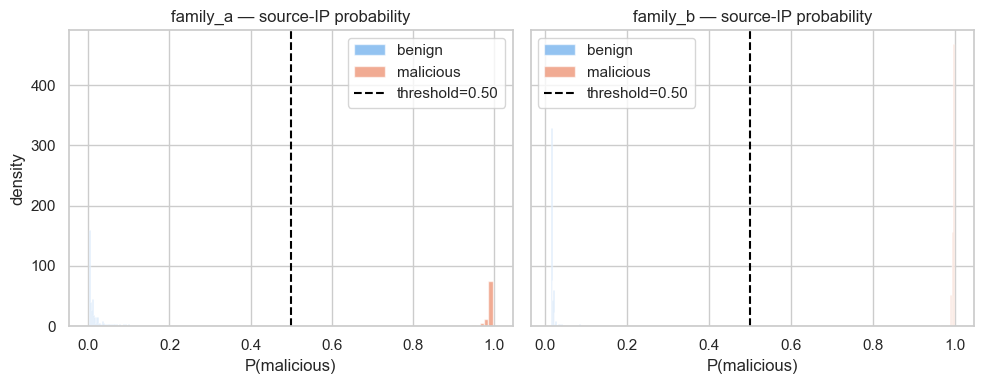

In [32]:
families = sorted(all_source_predictions["family"].unique())
fig, axes = plt.subplots(1, len(families), figsize=(5 * len(families), 4), sharey=True)
if len(families) == 1:
    axes = [axes]

for ax, fam in zip(axes, families):
    fam_df = all_source_predictions[
        (all_source_predictions["family"] == fam)
        & (all_source_predictions["split"] == "validation")
    ]
    for label, color, name in [(0, "#4C9BE8", "benign"), (1, "#E8744C", "malicious")]:
        subset = fam_df[fam_df["is_malicious_source"] == label]["malicious_probability"]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
    thr = family_artifacts[fam].source_threshold
    ax.axvline(thr, color="black", linestyle="--", label=f"threshold={thr:.2f}")
    ax.set_title(f"{fam} — source-IP probability")
    ax.set_xlabel("P(malicious)")
    ax.legend()

axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

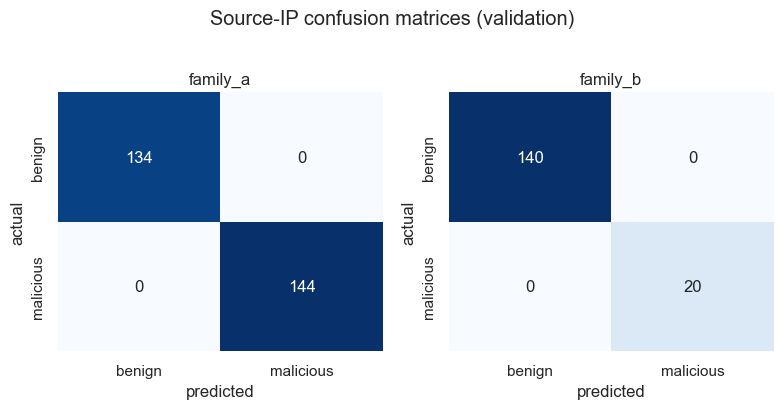

In [33]:
fig, axes = plt.subplots(1, len(families), figsize=(4 * len(families), 4))
if len(families) == 1:
    axes = [axes]

for ax, fam in zip(axes, families):
    fam_df = all_source_predictions[
        (all_source_predictions["family"] == fam)
        & (all_source_predictions["split"] == "validation")
    ]
    cm = confusion_matrix(fam_df["is_malicious_source"], fam_df["predicted_source"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["benign", "malicious"],
        yticklabels=["benign", "malicious"],
    )
    ax.set_title(f"{fam}")
    ax.set_xlabel("predicted")
    ax.set_ylabel("actual")

plt.suptitle("Source-IP confusion matrices (validation)", y=1.02)
plt.tight_layout()
plt.show()

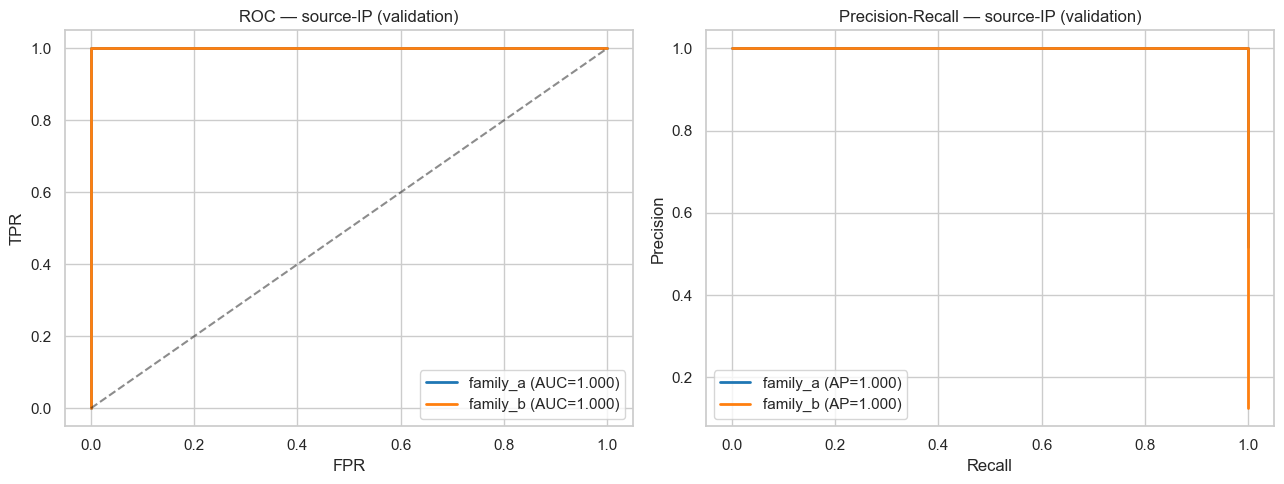

In [34]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5))

for fam in families:
    fam_df = all_source_predictions[
        (all_source_predictions["family"] == fam)
        & (all_source_predictions["split"] == "validation")
    ]
    y_true = fam_df["is_malicious_source"]
    y_score = fam_df["malicious_probability"]
    color = FAMILY_PALETTE[fam]

    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax_roc.plot(fpr, tpr, color=color, lw=2, label=f"{fam} (AUC={auc(fpr, tpr):.3f})")

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    ax_pr.plot(rec, prec, color=color, lw=2, label=f"{fam} (AP={ap:.3f})")

ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax_roc.set(xlabel="FPR", ylabel="TPR", title="ROC — source-IP (validation)")
ax_roc.legend(loc="lower right")

ax_pr.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall — source-IP (validation)")
ax_pr.legend(loc="lower left")

plt.tight_layout()
plt.show()

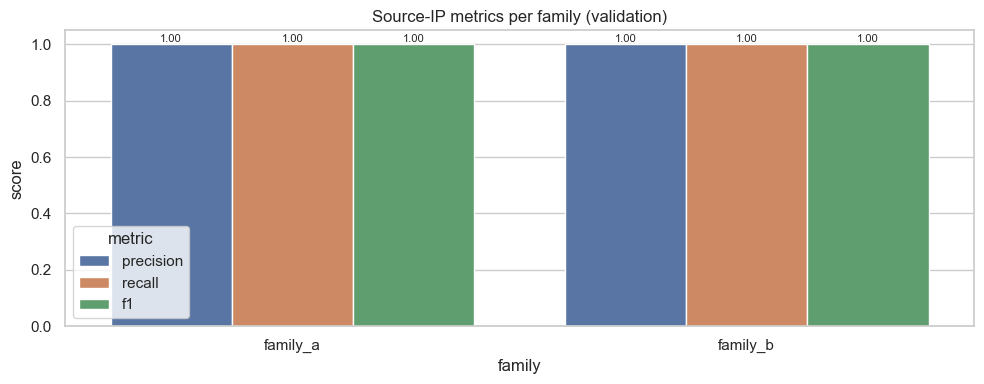

,family,split,n,precision,recall,f1
0,family_a,test,296,1.0,1.0,1.0
1,family_a,train,1076,1.0,1.0,1.0
2,family_a,validation,278,1.0,1.0,1.0
3,family_b,test,153,1.0,1.0,1.0
4,family_b,train,625,1.0,1.0,1.0
5,family_b,validation,160,1.0,1.0,1.0


In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for (fam, split), grp in all_source_predictions.groupby(["family", "split"]):
    rows.append({
        "family": fam,
        "split": split,
        "n": len(grp),
        "precision": precision_score(grp["is_malicious_source"], grp["predicted_source"], zero_division=0),
        "recall":    recall_score(grp["is_malicious_source"], grp["predicted_source"], zero_division=0),
        "f1":        f1_score(grp["is_malicious_source"], grp["predicted_source"], zero_division=0),
    })
metrics_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 4))
plot_df = metrics_df.melt(
    id_vars=["family", "split"],
    value_vars=["precision", "recall", "f1"],
    var_name="metric", value_name="score",
)
sns.barplot(
    data=plot_df[plot_df["split"] == "validation"],
    x="family", y="score", hue="metric", ax=ax,
)
ax.set_ylim(0, 1.05)
ax.set_title("Source-IP metrics per family (validation)")
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.2f}", (p.get_x() + p.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

metrics_df.round(4)

ValueError: Could not interpret value `dataset_label` for `x`. An entry with this name does not appear in `data`.

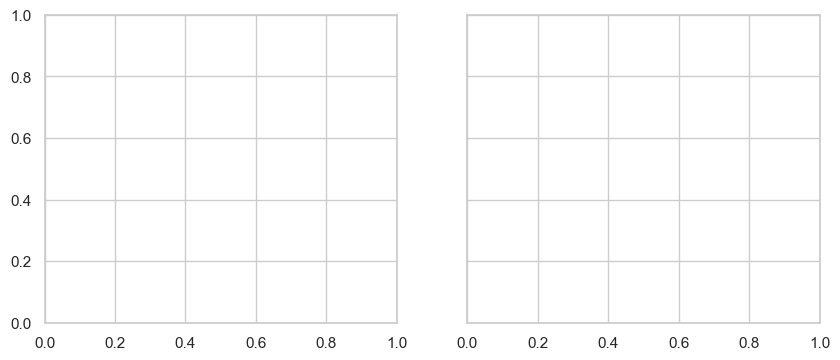

In [38]:
fig, axes = plt.subplots(1, len(families), figsize=(5 * len(families), 4), sharey=True)
if len(families) == 1:
    axes = [axes]

for ax, fam in zip(axes, families):
    sub = all_dataset_predictions[
        (all_dataset_predictions["family"] == fam)
        & (all_dataset_predictions["split"] == "validation")
    ]
    sns.stripplot(
        data=sub, x="dataset_label", y="max_source_probability",
        hue="predicted_dataset_label",
        palette={0: "#4C9BE8", 1: "#E8744C"},
        jitter=0.25, alpha=0.8, ax=ax,
    )
    thr = family_artifacts[fam].dataset_threshold
    ax.axhline(thr, color="black", linestyle="--", label=f"threshold={thr:.2f}")
    ax.set_title(f"{fam} — dataset scoring")
    ax.set_xlabel("true dataset label")
    ax.set_ylabel("max source P(malicious)")
    ax.legend(title="predicted", loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(
    data=final_predictions,
    x="family", y="shortlisted_source_count",
    hue="split", ax=ax,
)
ax.set_title("Shortlisted source-IP count per dataset")
ax.set_ylabel("# source IPs flagged")
plt.tight_layout()
plt.show()

# Summary table
(final_predictions
    .groupby(["family", "split"])["shortlisted_source_count"]
    .describe()[["count", "mean", "50%", "max"]]
    .round(2))

KeyError: 'dataset_label'

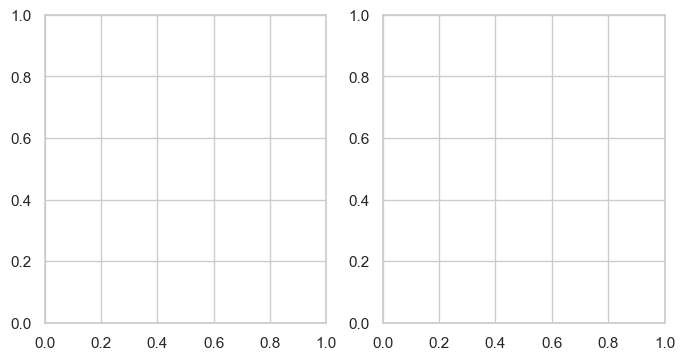

In [37]:
fig, axes = plt.subplots(1, len(families), figsize=(4 * len(families), 4))
if len(families) == 1:
    axes = [axes]

for ax, fam in zip(axes, families):
    sub = final_predictions[
        (final_predictions["family"] == fam)
        & (final_predictions["split"] == "validation")
    ]
    cm = confusion_matrix(sub["dataset_label"], sub["predicted_dataset_label"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Greens", cbar=False, ax=ax,
        xticklabels=["clean", "infected"],
        yticklabels=["clean", "infected"],
    )
    ax.set_title(f"{fam} — dataset CM")
    ax.set_xlabel("predicted")
    ax.set_ylabel("actual")

plt.suptitle("Dataset-level confusion matrices (validation)", y=1.02)
plt.tight_layout()
plt.show()